In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

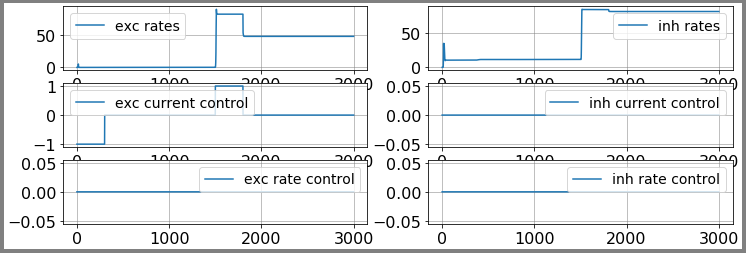

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

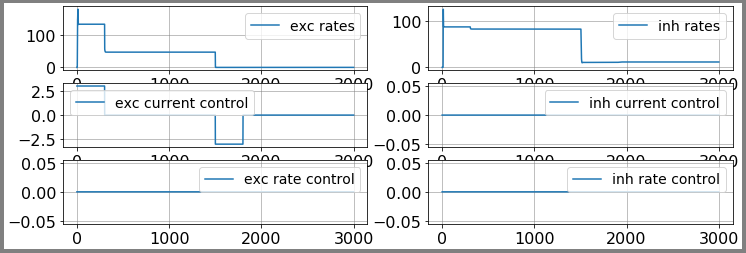

low state vars =  [ 8.2469e-02  1.1638e+01  4.3314e-01  7.5957e-01  0.0000e+00  1.6029e-02
  6.3812e-01  1.4997e-02  7.8014e-01  9.5893e-04  6.6523e-03  8.4016e-04
  6.5247e-03  0.0000e+00  0.0000e+00  7.1463e-01  5.5403e-01 -5.6298e+01
  2.7100e+01  6.3823e+00]


In [4]:
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

In [5]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 50

initVars = low_state_vars

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 
                    0.8, 0.8, 0.8, 0.8, 0.8 ]

sheet = "line_search"

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])

In [6]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

## 0

In [45]:
# A.0.a)

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    line_search_ = "AG", control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])


set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  9567.806570427567
RUN  2 , total integrated cost =  5524.443183340146
RUN  3 , total integrated cost =  1871.884955539555
RUN  4 , total integrated cost =  1207.805723414706
RUN  5 , total integrated cost =  75.23538472440245
RUN  6 , total integrated cost =  4.078336682539981
RUN  7 , total integrated cost =  2.6100849473877528
RUN  8 , total integrated cost =  1.8338508965320954
RUN  9 , total integrated cost =  1.654966947122862
RUN  10 , total integrated cost =  1.5779865609317825
RUN  11 , total integrated cost =  1.4799467968071522
RUN  12 , total integrated cost =  1.4037882341419727
RUN  13 , total integrated cost =  1.3433843889087844
RUN  14 , total integrated cost =  1.2651702388620025
RUN  15 , total integrated cost =  1.172118782532677
RUN  16 , total integrated cost =  1.136966882878656
R

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  0.33520780152682456
RUN  50 , total integrated cost =  0.33520780152682456
Improved over  50  iterations in  2.018978099999913  seconds by  99.99850975666058  percent.
Problem in initial value trasfer:  Vmean_exc -56.17435815574947 -56.174380381818416


In [ ]:
"""
None
Improved over  50  iterations in  1.8102619000000004  seconds by  99.99974010392312  percent.

HS
Improved over  50  iterations in  1.8062891999999806  seconds by  99.99999995855913  percent.

FR
Improved over  50  iterations in  1.8924801000000002  seconds by  92.01985282262399  percent.

PR
Improved over  50  iterations in  1.8609384999999747  seconds by  99.99999949411986  percent.

CD
Improved over  50  iterations in  1.8022551999999905  seconds by  86.99966411364294  percent.

LS
Improved over  50  iterations in  1.7268142000000353  seconds by  99.99999988631068  percent.

DS
Improved over  50  iterations in  1.8204011000000264  seconds by  92.09401973573362  percent.

WYL
Improved over  50  iterations in  1.8658662000000277  seconds by  99.99999926619728  percent.

HZ
Improved over  50  iterations in  1.9096458999999868  seconds by  99.99997198388057  percent.


----------------------- AG line search
None
Improved over  50  iterations in  2.018978099999913  seconds by  99.99850975666058  percent.

HS
Improved over  50  iterations in  1.824688800000331  seconds by  99.99999866244939  percent.

HZ
Improved over  50  iterations in  2.0452236999999514  seconds by  99.99981395664638  percent.
"""

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  3141.686679547111
RUN  2 , total integrated cost =  2000.75643305626
RUN  3 , total integrated cost =  332.08160101041057
RUN  4 , total integrated cost =  240.7310895479688
RUN  5 , total integrated cost =  215.09153075987894
RUN  6 , total integrated cost =  195.42247038608716
RUN  7 , total integrated cost =  178.18732808183816
RUN  8 , total integrated cost =  162.79804879513833
RUN  9 , total integrated cost =  148.53428801283584
RUN  10 , total integrated cost =  135.53606593250817
RUN  11 , total integrated cost =  123.79517653275931
RUN  12 , total integrated cost =  113.18423795629627
RUN  13 , total integrated cost =  104.36980695976924
RUN  14 , total integrated cost =  97.12832406725903
RUN  15 , total integrated cost =  92.17781385514817
RUN  16 , total integrated cost =  88.89536369042806
RUN  17 , total integrated cost =  86.2242090

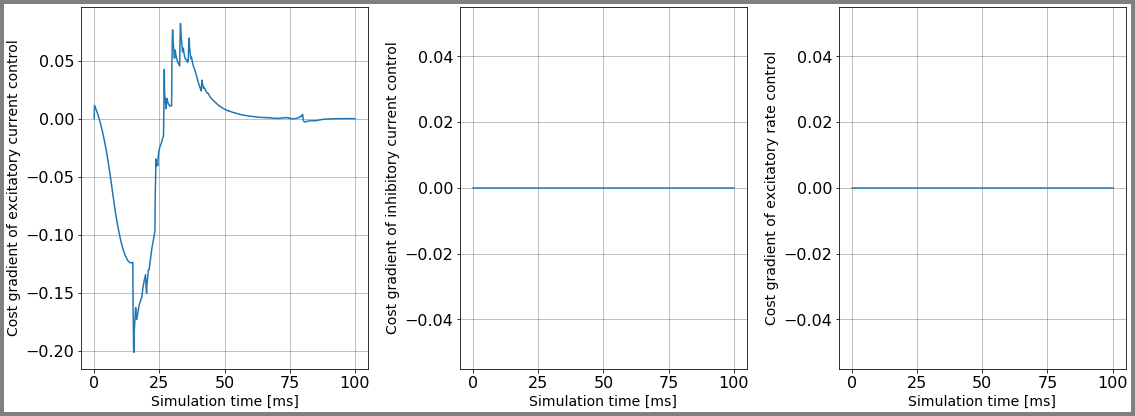

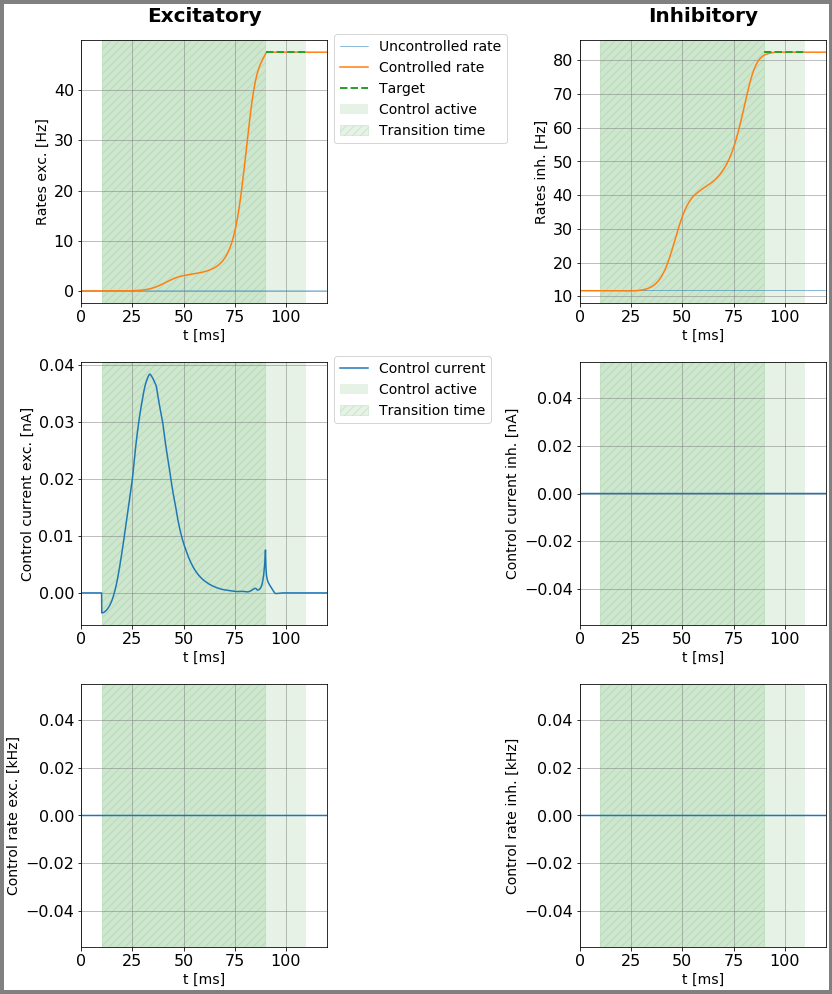

In [8]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 0
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 2

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  148.06704874286902
RUN  2 , total integrated cost =  0.019482703224128563
RUN  3 , total integrated cost =  1.3991798011876972e-05
RUN  4 , total integrated cost =  3.15409267696405e-08
RUN  5 , total integrated cost =  2.3682373689204103e-11
RUN  6 , total integrated cost =  2.990562677098877e-14
RUN  7 , total integrated cost =  3.142213208193214e-17
RUN  8 , total integrated cost =  2.824418887913895e-20
RUN  9 , total integrated cost =  1.314026796737288e-20
RUN  10 , total integrated cost =  1.427298935269898e-22
RUN  11 , total integrated cost =  1.017054232268638e-22
RUN  12 , total integrated cost =  7.825041504507708e-23
RUN  13 , total integrated cost =  4.934764452344949e-23
RUN  14 , total integrated cost =  9.607694736867786e-26
RUN  15 , total integrated cost =  8.071119911242054e-26
RUN 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  7.836102470358607e-26
Control only changes marginally.
RUN  19 , total integrated cost =  7.836102470358607e-26
Improved over  19  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7019128213918413
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.549582175049956


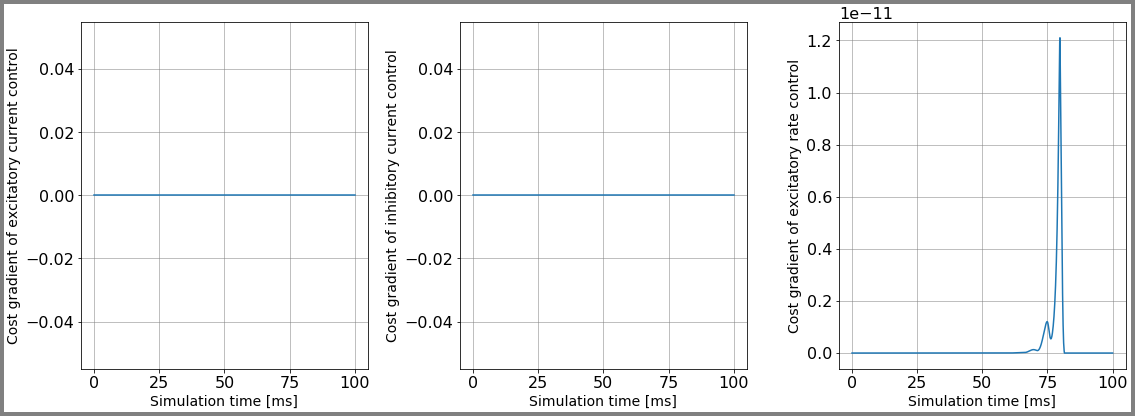

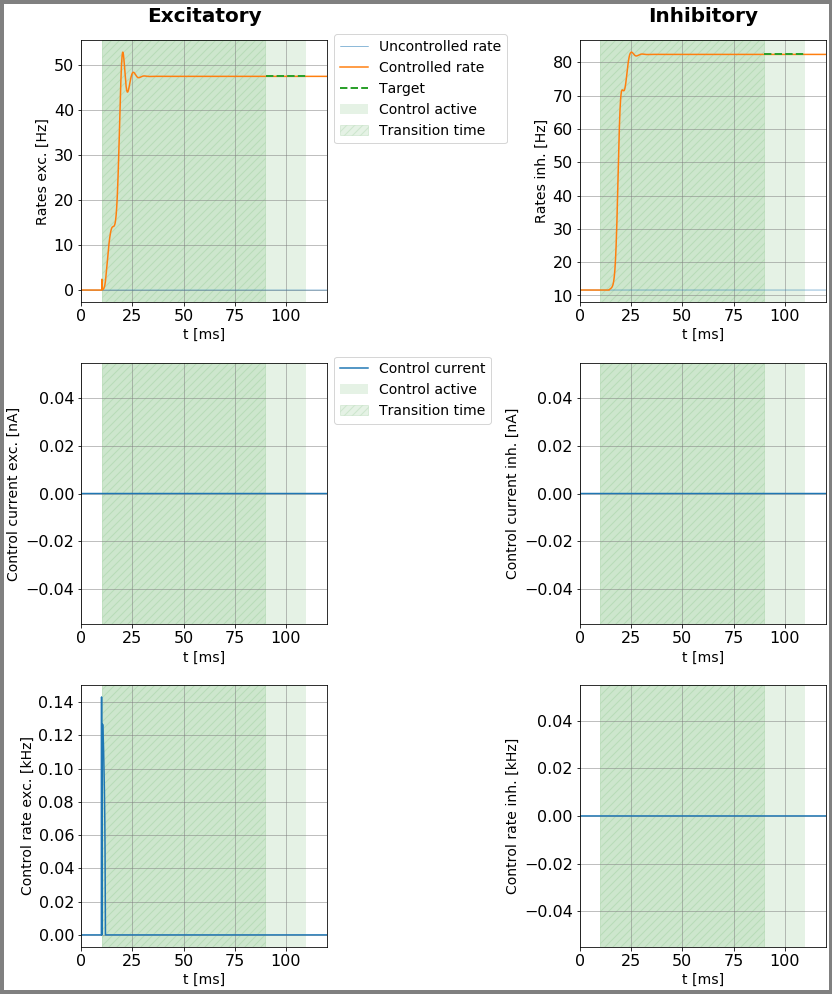

In [20]:
case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  34.020009982611114
RUN  2 , total integrated cost =  19.807597950538742
RUN  3 , total integrated cost =  0.46008816412680714
RUN  4 , total integrated cost =  0.19796980480806817
RUN  5 , total integrated cost =  0.1944391145512246
RUN  6 , total integrated cost =  0.19140626876890396
RUN  7 , total integrated cost =  0.19039303112624623
RUN  8 , total integrated cost =  0.18924907733211738
RUN  9 , total integrated cost =  0.18831946204015404
RUN  10 , total integrated cost =  0.18830612819500134
RUN  11 , total integrated cost =  0.18829523701928735
RUN  12 , total integrated cost =  0.18828275996354396
RUN  13 , total integrated cost =  0.18827159159926088
RUN  14 , total integrated cost =  0.1882598193444573
RUN  15 , total integrated cost =  0.18824963409609094
RUN  16 , total integrated cost =  0.18823841605240668
RUN  17 , total integrated

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  4320 , total integrated cost =  0.18313459292418588
Improved over  4320  iterations by  99.99918583306808  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144683230476364
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.10578199925241


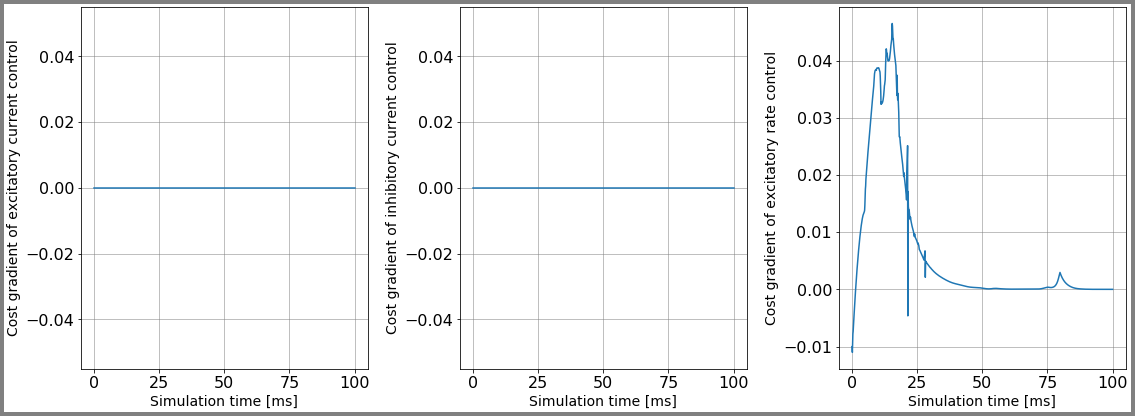

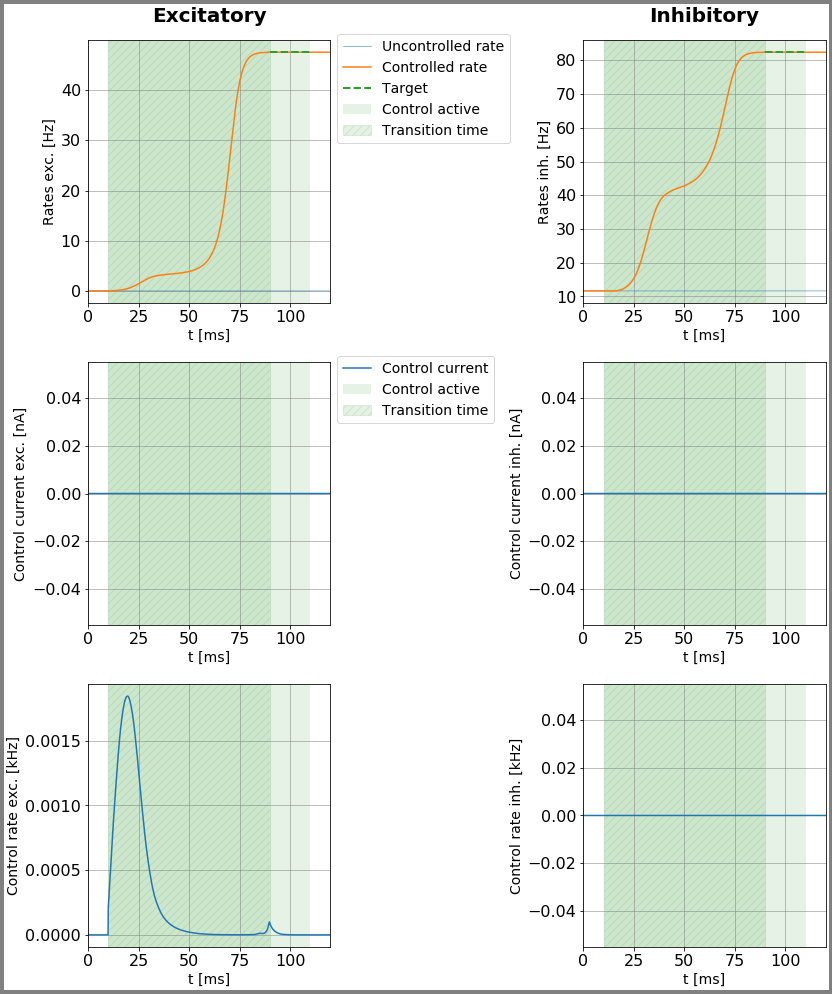

In [21]:
case_ind = 2
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 4

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  3859.672296503376
RUN  2 , total integrated cost =  88.30540409162167
RUN  3 , total integrated cost =  1.2412311560575862
RUN  4 , total integrated cost =  0.0598230614877892
RUN  5 , total integrated cost =  0.029961637979352862
RUN  6 , total integrated cost =  0.002949038737146899
RUN  7 , total integrated cost =  0.0015037102635284587
RUN  8 , total integrated cost =  0.0011131193937577847
RUN  9 , total integrated cost =  0.0008873623634675265
RUN  10 , total integrated cost =  0.0007342924806327018
RUN  11 , total integrated cost =  0.0006198705246234058
RUN  12 , total integrated cost =  0.000528319977673254
RUN  13 , total integrated cost =  0.00045085164027131844
RUN  14 , total integrated cost =  0.00038826517153170214
RUN  15 , total integrated cost =  0.0003383981276602466
RUN  16 , total 

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  6.78385500314227e-09
RUN  5000 , total integrated cost =  6.78385500314227e-09
Improved over  5000  iterations by  99.99999999996984  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459229097624 -56.17459451192863


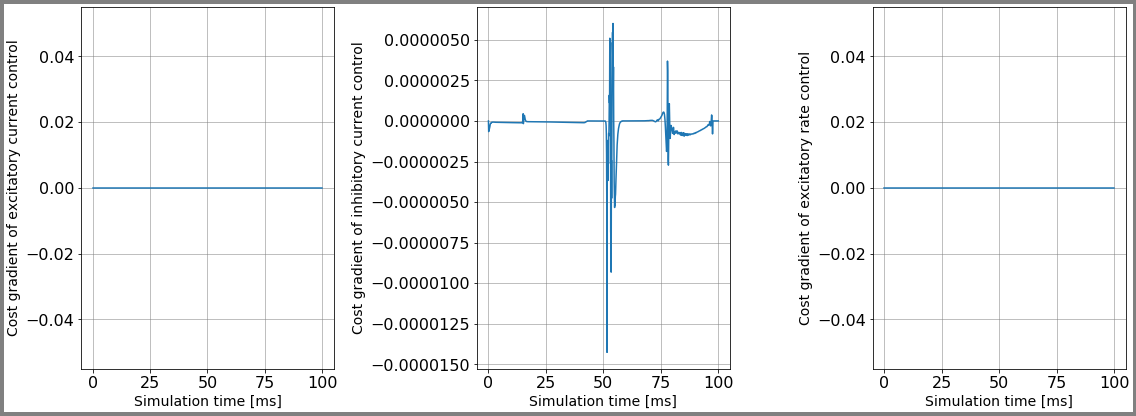

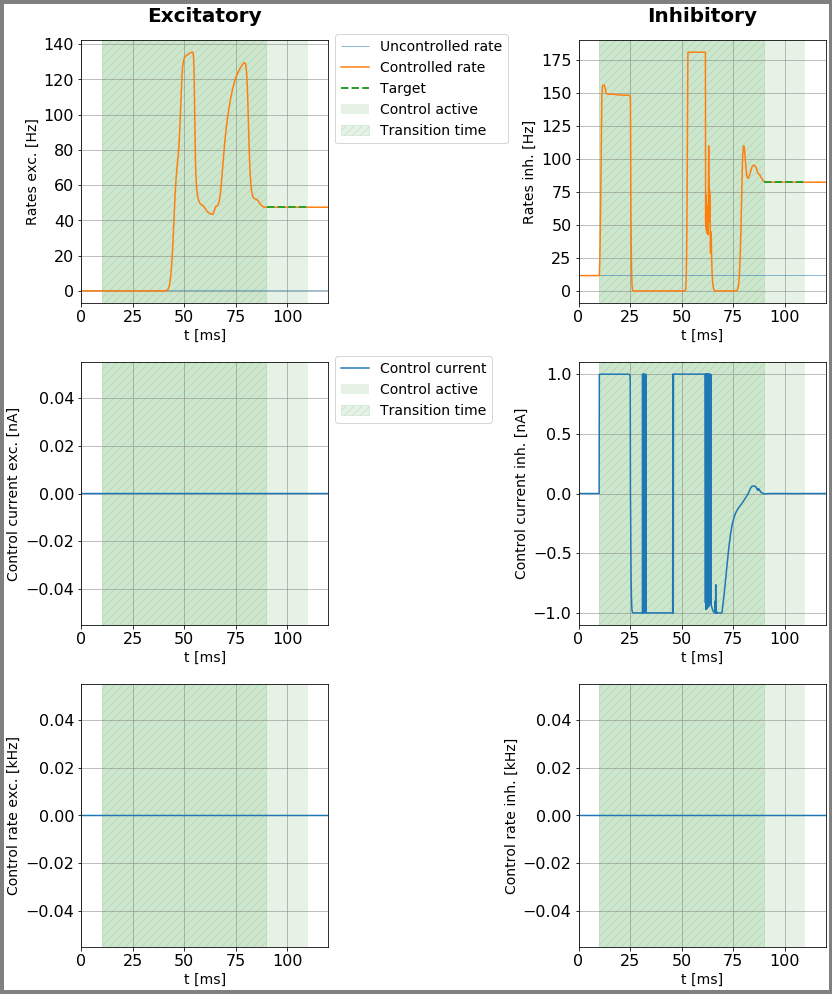

In [22]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  3987.383781311129
RUN  2 , total integrated cost =  391.5036034396181
RUN  3 , total integrated cost =  271.329872761392
RUN  4 , total integrated cost =  37.15248771413067
RUN  5 , total integrated cost =  35.188603367451826
RUN  6 , total integrated cost =  32.15009528236786
RUN  7 , total integrated cost =  30.685082929882466
RUN  8 , total integrated cost =  28.23143202880135
RUN  9 , total integrated cost =  26.916841816650663
RUN  10 , total integrated cost =  25.41596009751184
RUN  11 , total integrated cost =  24.58468476830884
RUN  12 , total integrated cost =  23.67348654066481
RUN  13 , total integrated cost =  23.10533681573736
RUN  14 , total integrated cost =  22.63175818424772
RUN  15 , total integrated cost =  22.298284430832005
RUN  16 , total integrated cost =  19.976450504845396
RUN  17 , total integrated cost =  19.892963147911

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  14.827230343436657
RUN  5000 , total integrated cost =  14.827230343436657
Improved over  5000  iterations by  99.9340821390173  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459054295453 -56.174590570881506


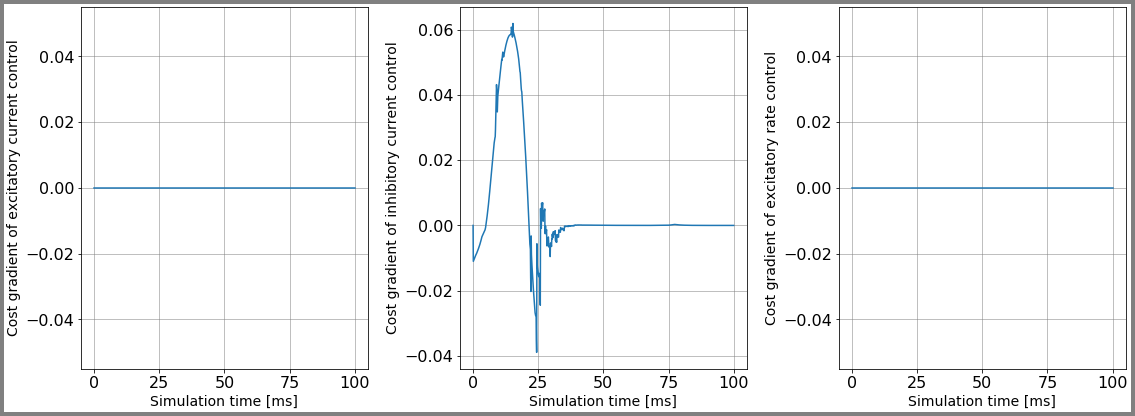

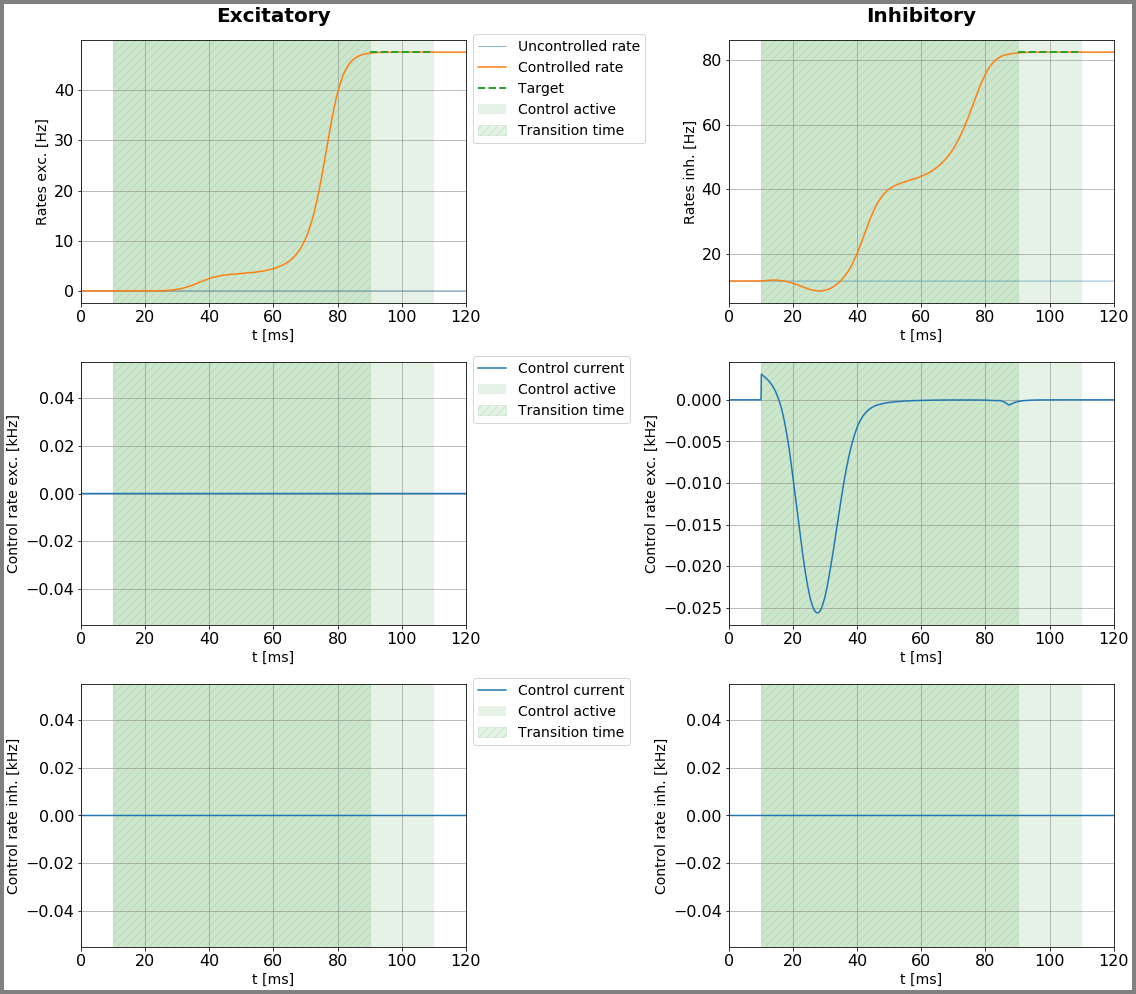

In [36]:
case_ind = 4
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  2949.072608149174
RUN  2 , total integrated cost =  1727.5249571588436
RUN  3 , total integrated cost =  537.9247471416692
RUN  4 , total integrated cost =  310.94839325314246
RUN  5 , total integrated cost =  199.0846206850091
RUN  6 , total integrated cost =  132.08026047641465
RUN  7 , total integrated cost =  89.81125768788664
RUN  8 , total integrated cost =  64.6722086266404
RUN  9 , total integrated cost =  47.648911482440894
RUN  10 , total integrated cost =  36.7603536670014
RUN  11 , total integrated cost =  29.258933102448715
RUN  12 , total integrated cost =  23.906448836445445
RUN  13 , total integrated cost =  20.032118726877286
RUN  14 , total integrated cost =  17.095538808581622
RUN  15 , total integrated cost =  14.780863171054927
RUN  16 , total integrated cost =  12.9472213128782

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  1.899037938887123e-09
RUN  5000 , total integrated cost =  1.899037938887123e-09
Improved over  5000  iterations by  99.99999999999156  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459010342946 -56.17458549738905


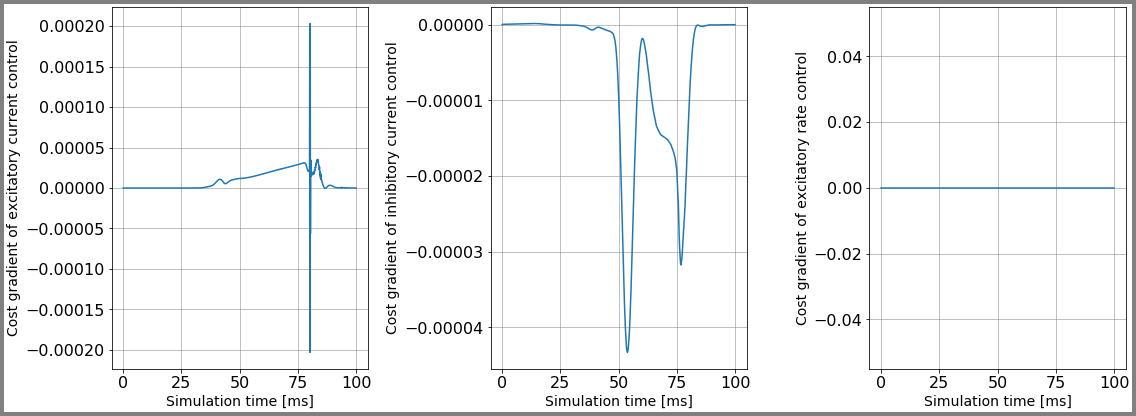

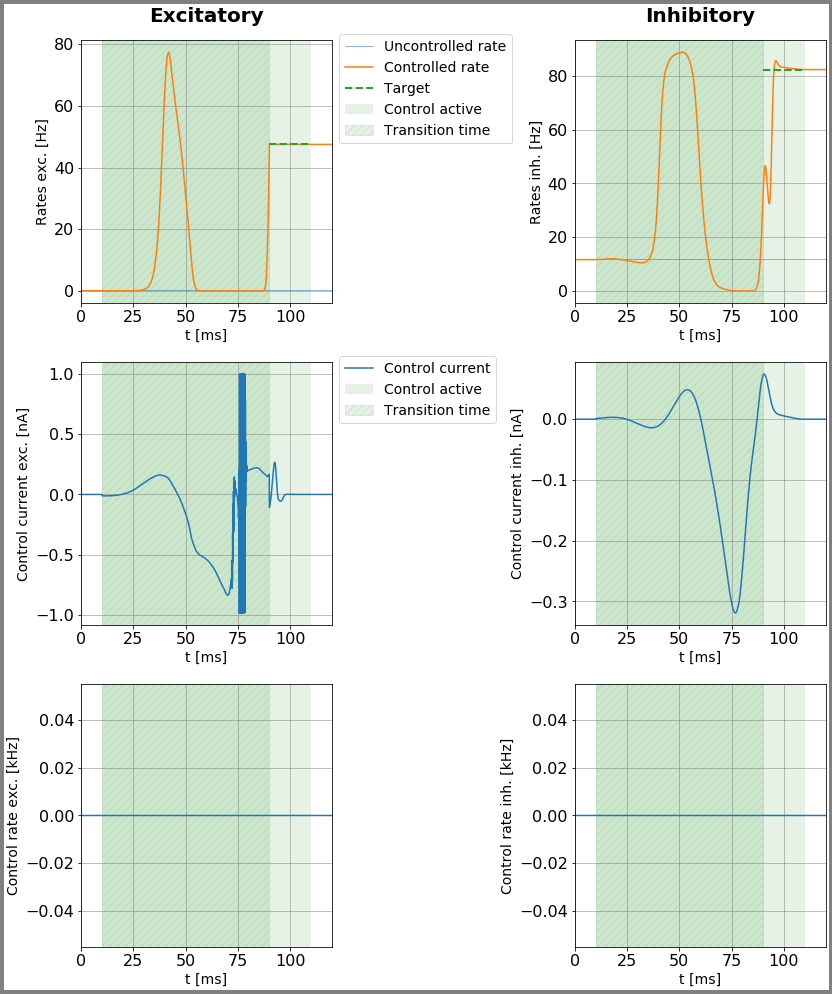

In [24]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  3141.686679547111
RUN  2 , total integrated cost =  2000.75643305626
RUN  3 , total integrated cost =  332.08160101041057
RUN  4 , total integrated cost =  240.7310895479688
RUN  5 , total integrated cost =  215.09153075987894
RUN  6 , total integrated cost =  195.42247038608716
RUN  7 , total integrated cost =  178.18732808183816
RUN  8 , total integrated cost =  162.79804879513833
RUN  9 , total integrated cost =  148.53428801283584
RUN  10 , total integrated cost =  135.53606593250817
RUN  11 , total integrated cost =  123.79517653275931
RUN  12 , total integrated cost =  113.18423795629627
RUN  13 , total integrated cost =  104.36980695976924
RUN  14 , total integrated cost =  97.12832406725903
RUN  15 , total integrated cost =  90.614298265764
RUN  16 , total integrated cost =  86.02060522168972
RUN  17 , total integrated cost =  83.126277973

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  3876 , total integrated cost =  14.827766192141194
Improved over  3876  iterations by  99.9340797567787  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459053816172 -56.17459056627061


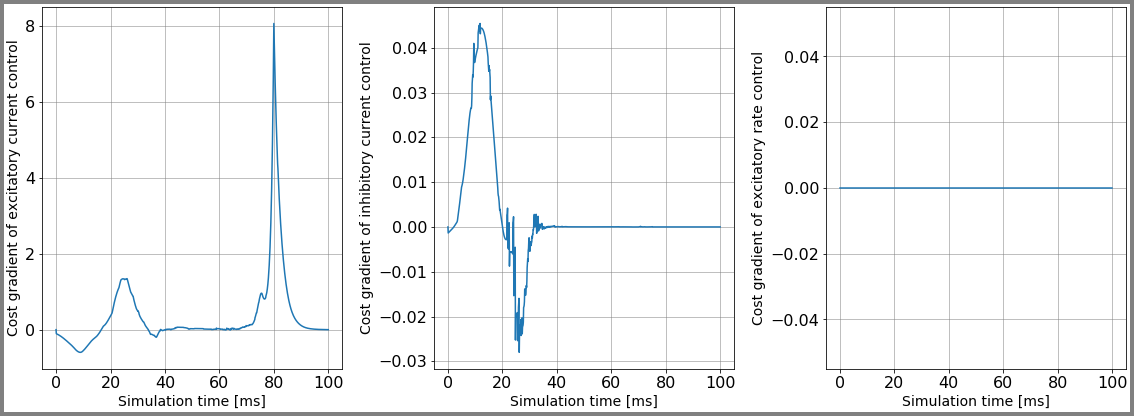

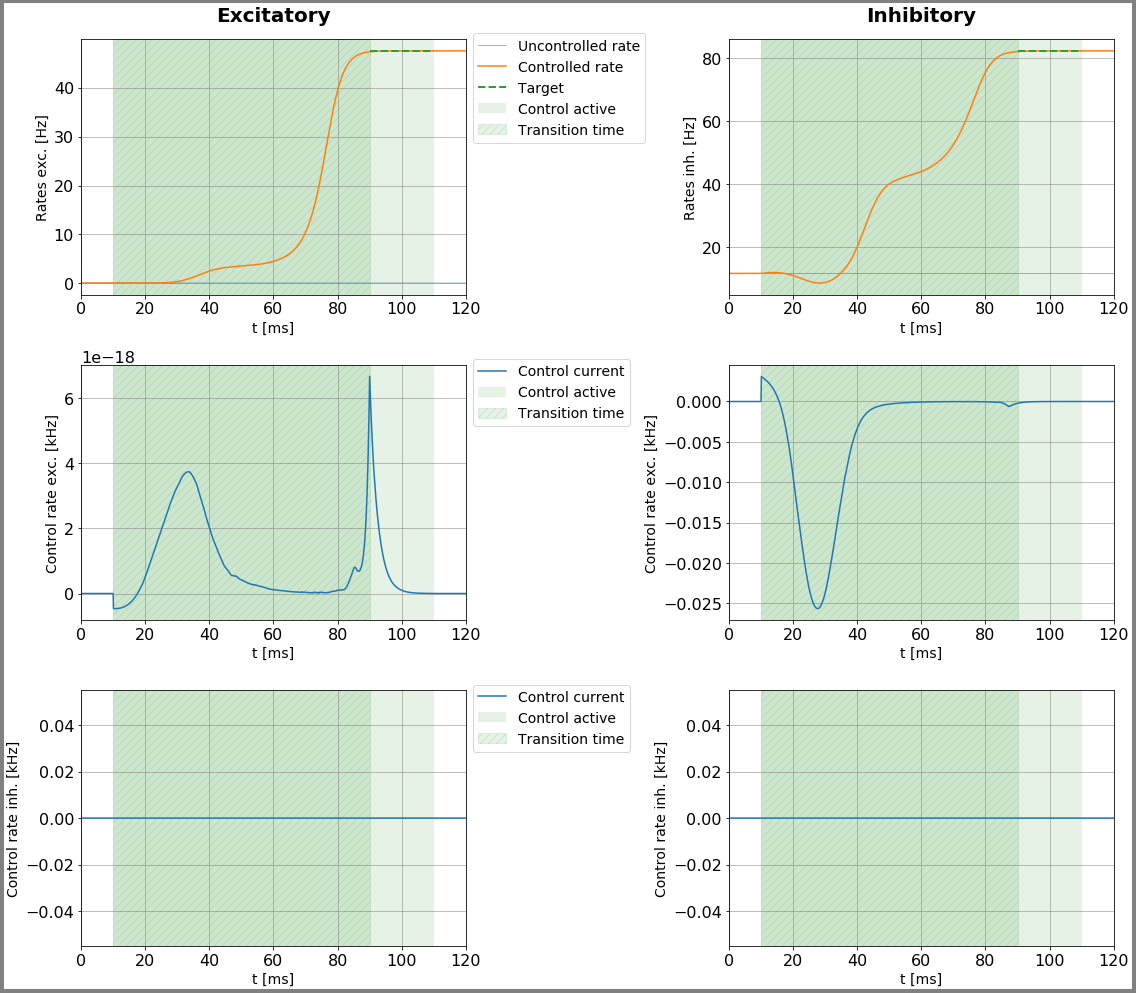

In [37]:
case_ind = 6
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  27.58553689486353
RUN  2 , total integrated cost =  0.0006605384771172418
RUN  3 , total integrated cost =  8.69331105841634e-06
RUN  4 , total integrated cost =  1.4966818176543569e-06
RUN  5 , total integrated cost =  6.17330719943315e-07
RUN  6 , total integrated cost =  3.4789086878669715e-07
RUN  7 , total integrated cost =  1.9856749218989483e-07
RUN  8 , total integrated cost =  1.3817056046740082e-07
RUN  9 , total integrated cost =  9.454458583043152e-08
RUN  10 , total integrated cost =  7.098094330637573e-08
RUN  11 , total integrated cost =  5.0545861794724395e-08
RUN  12 , total integrated cost =  3.981040768630873e-08
RUN  13 , total integrated cost =  3.157289343782386e-08
RUN  14 , total integrated cost =  2.6237739629542868e-08
RUN  15 , total integrated cost =  2.0207094365377565e-

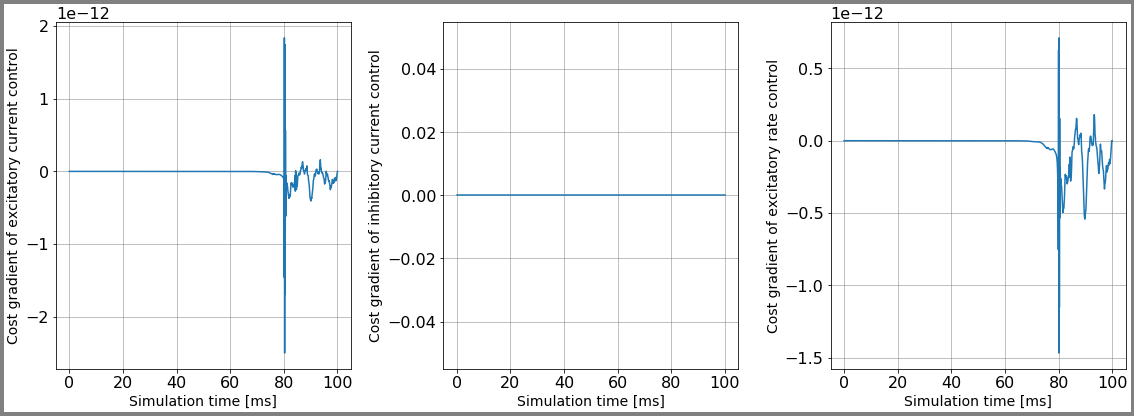

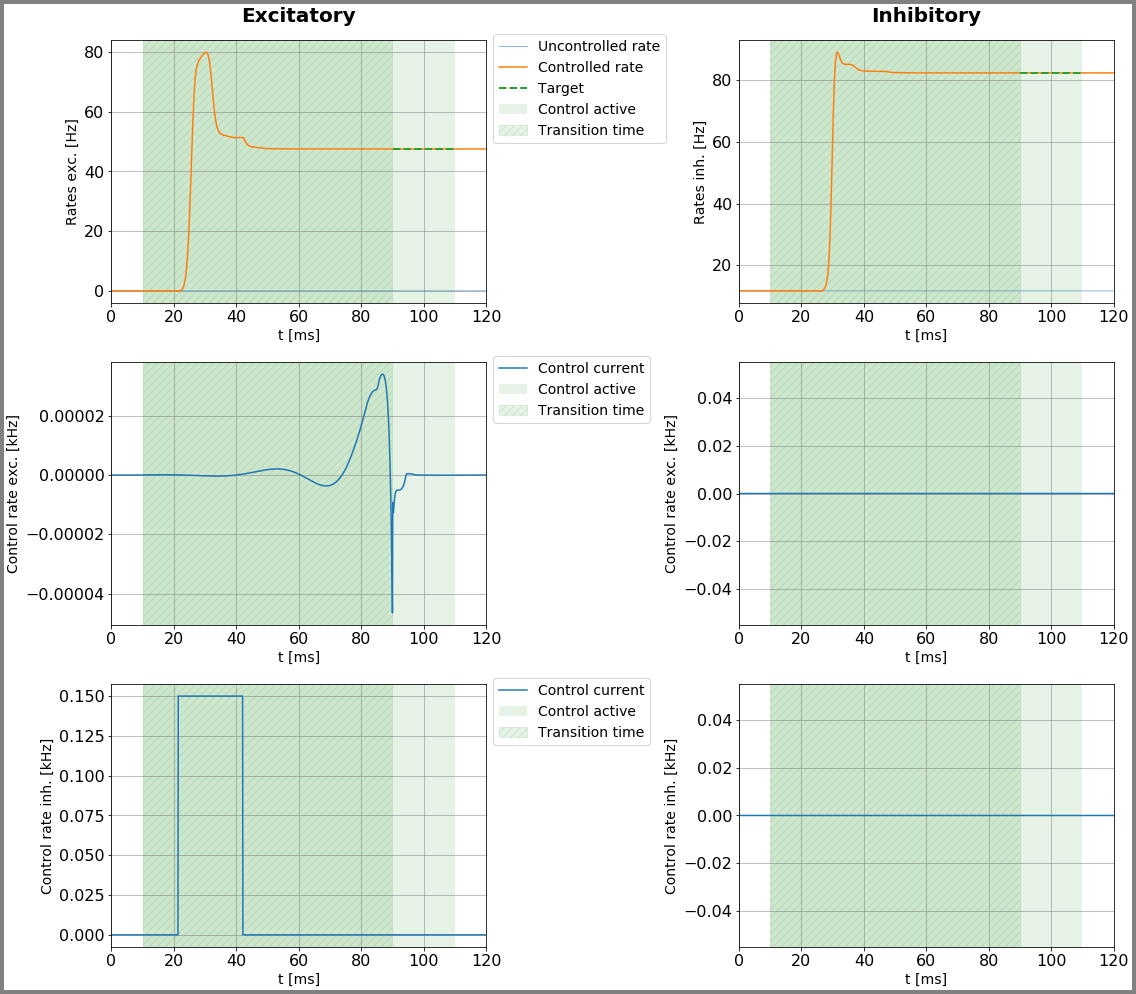

In [38]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  34.020009982611114
RUN  2 , total integrated cost =  13.051086300642215
RUN  3 , total integrated cost =  12.897879490007034
RUN  4 , total integrated cost =  11.680778274834374
RUN  5 , total integrated cost =  9.426865733786634
RUN  6 , total integrated cost =  7.562803900084364
RUN  7 , total integrated cost =  6.085147549792788
RUN  8 , total integrated cost =  4.5802880821089795
RUN  9 , total integrated cost =  3.4321435862897323
RUN  10 , total integrated cost =  2.411438289077112
RUN  11 , total integrated cost =  1.4786801014367932
RUN  12 , total integrated cost =  0.6049969976393836
RUN  13 , total integrated cost =  0.27074315077227307
RUN  14 , total integrated cost =  0.20461868758543567
RUN  15 , total integrated cost =  0.20179468017531288
RUN  16 , total integrated cost =  0.20101546954704086
RUN  17 , total integrated cost =  0.2

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.18321178543326647
RUN  5000 , total integrated cost =  0.18321178543326647
Improved over  5000  iterations by  99.99918548989105  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.714624127640835
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.100427915358484


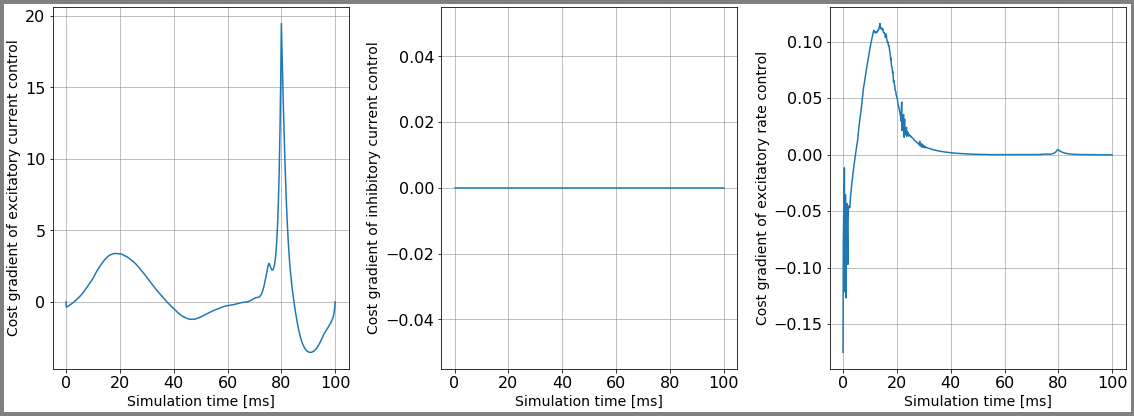

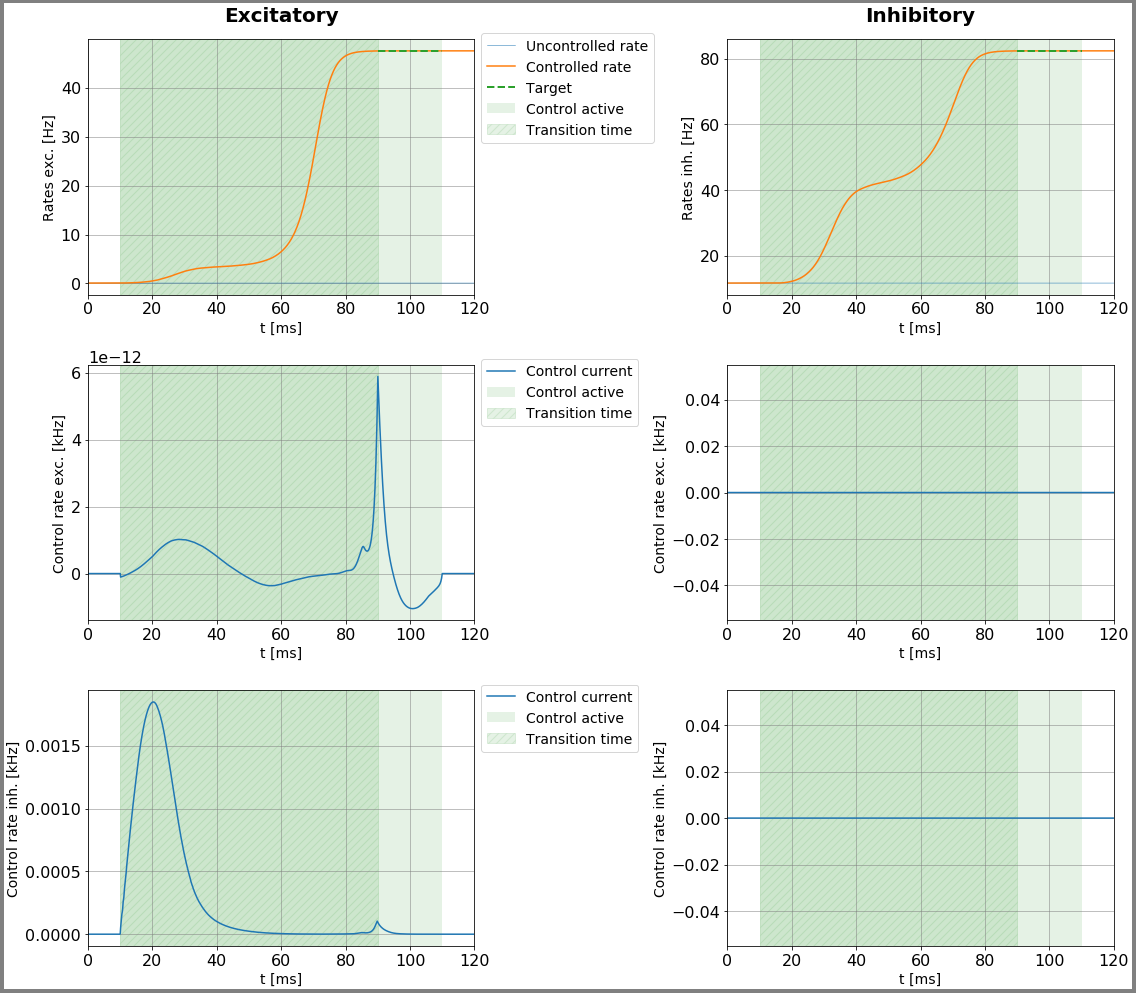

In [42]:
case_ind = 8
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  27.39253838494309
RUN  2 , total integrated cost =  1.9892711574687867e-05
RUN  3 , total integrated cost =  1.7548548052336057e-07
RUN  4 , total integrated cost =  3.353210289062334e-08
RUN  5 , total integrated cost =  1.5724756483453215e-08
RUN  6 , total integrated cost =  9.823228732046214e-09
RUN  7 , total integrated cost =  6.9435994890540055e-09
RUN  8 , total integrated cost =  5.25611575245087e-09
RUN  9 , total integrated cost =  4.166282407755538e-09
RUN  10 , total integrated cost =  3.4114086603078044e-09
RUN  11 , total integrated cost =  2.867975885847474e-09
RUN  12 , total integrated cost =  2.4537142635511308e-09
RUN  13 , total integrated cost =  2.0938164984607954e-09
RUN  14 , total integrated cost =  1.79075534740788e-09
RUN  15 , total integrated cost =  1.5703637107686714e

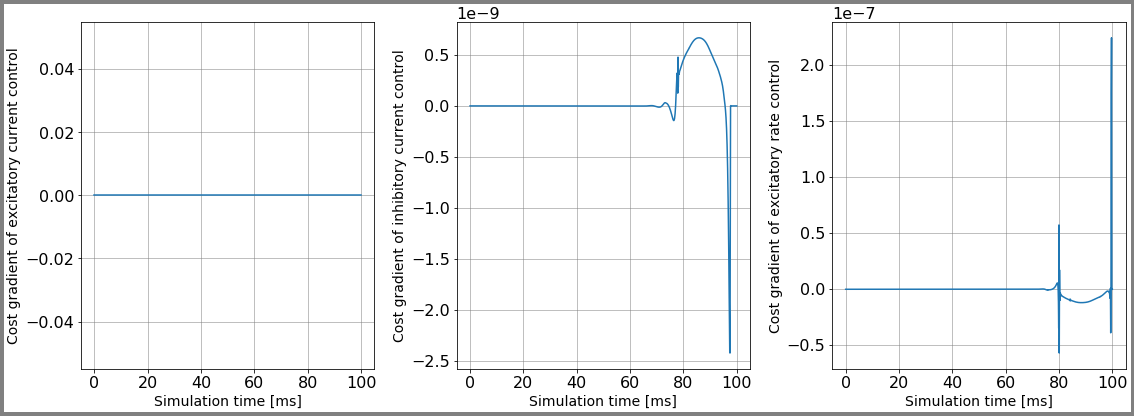

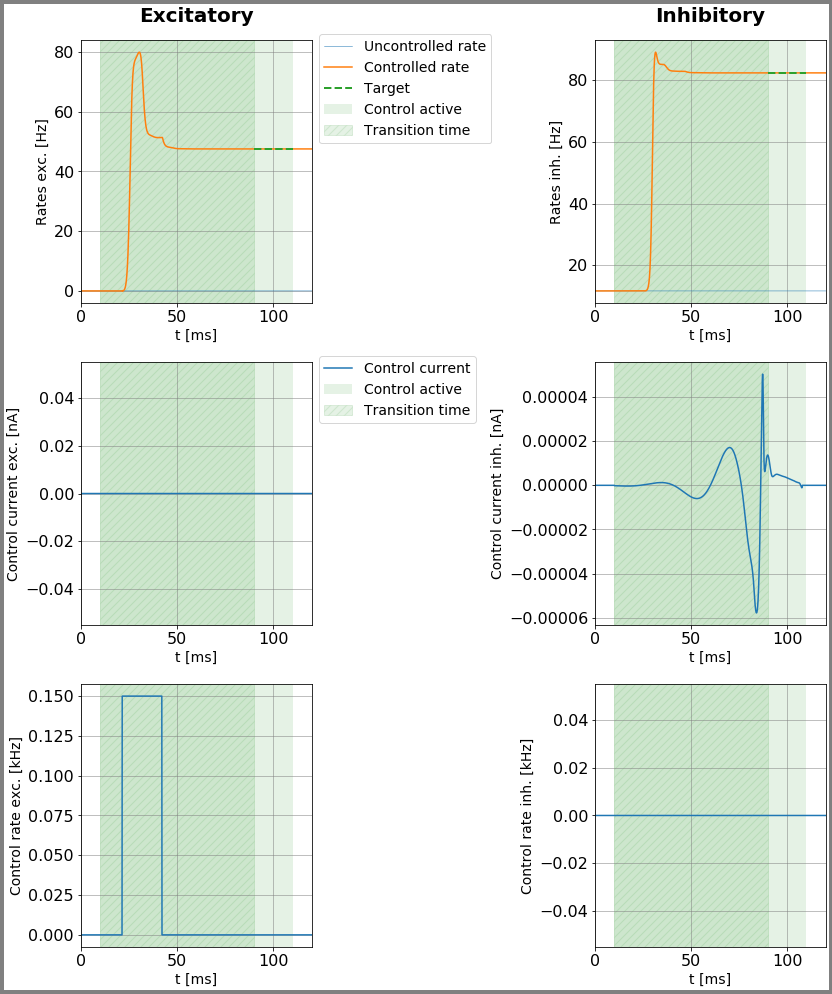

In [28]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  34.020009982611114
RUN  2 , total integrated cost =  19.807597950538742
RUN  3 , total integrated cost =  0.46008816412680714
RUN  4 , total integrated cost =  0.19796980480806817
RUN  5 , total integrated cost =  0.1944391145512246
RUN  6 , total integrated cost =  0.19140626876890396
RUN  7 , total integrated cost =  0.19039303112624623
RUN  8 , total integrated cost =  0.18924907733211738
RUN  9 , total integrated cost =  0.18831946204015404
RUN  10 , total integrated cost =  0.18830612819500134
RUN  11 , total integrated cost =  0.18829523701928735
RUN  12 , total integrated cost =  0.18828275996354396
RUN  13 , total integrated cost =  0.18827159159926088
RUN  14 , total integrated cost =  0.1882598193444573
RUN  15 , total integrated cost =  0.18824963409609094
RUN  16 , total integrated cost =  0.18823841605240668
RUN  17 , total integrated

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  4320 , total integrated cost =  0.18313459292418588
Improved over  4320  iterations by  99.99918583306808  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144683230476364
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.10578199925241


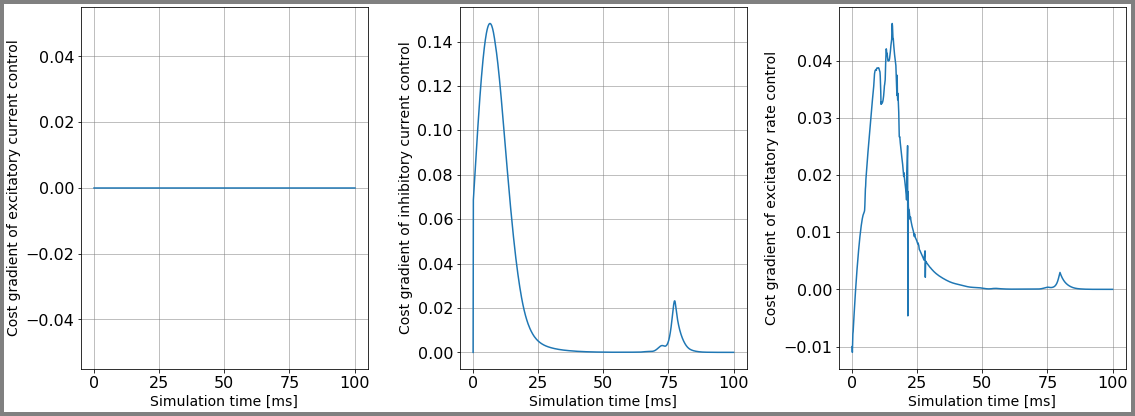

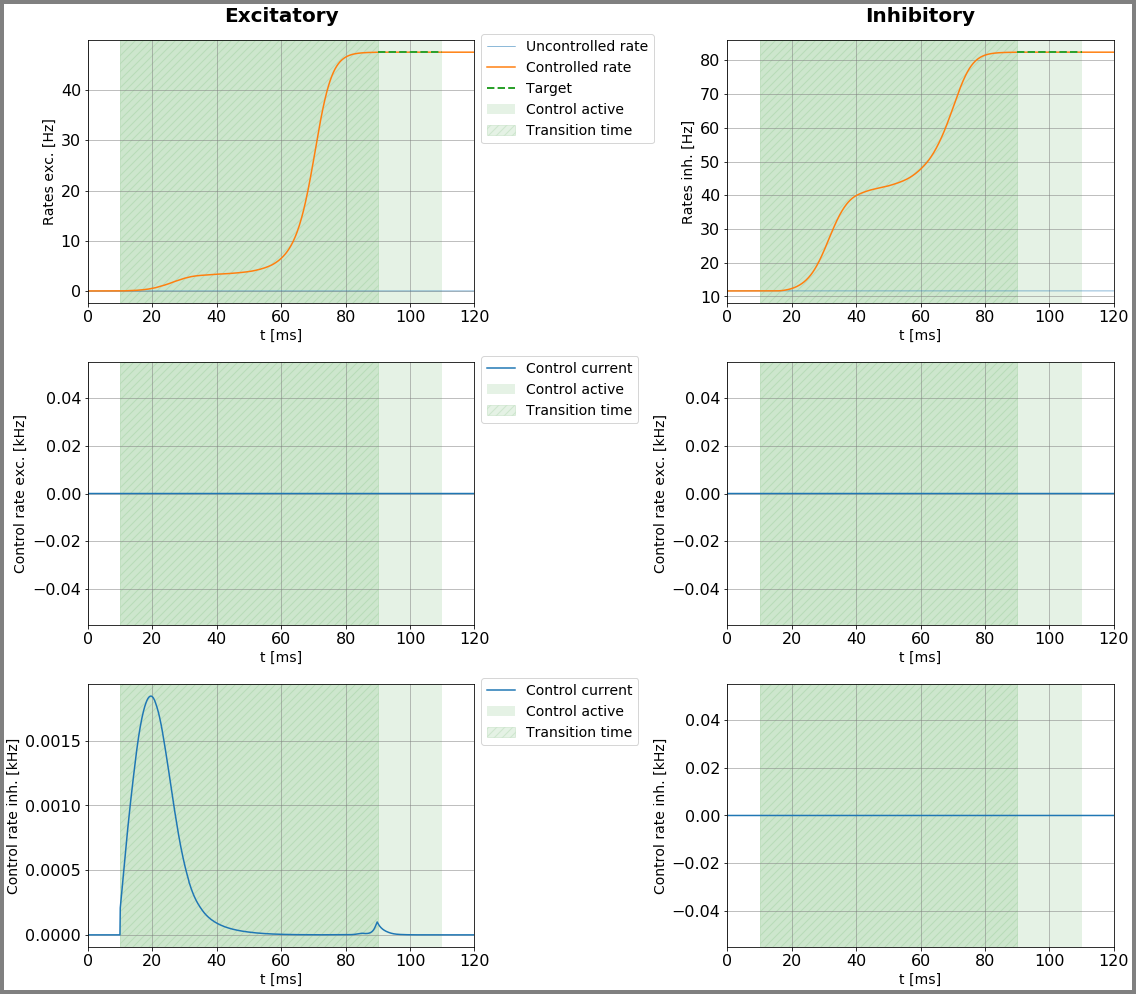

In [40]:
case_ind = 10
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  27.345093053090284
RUN  2 , total integrated cost =  8.611801904775583e-08
RUN  3 , total integrated cost =  1.1138096266646704e-09
RUN  4 , total integrated cost =  1.9136644235825035e-10
RUN  5 , total integrated cost =  7.899029147382485e-11
RUN  6 , total integrated cost =  4.444413007046732e-11
RUN  7 , total integrated cost =  2.5430108086228626e-11
RUN  8 , total integrated cost =  1.7665663112638786e-11
RUN  9 , total integrated cost =  1.2170954808151702e-11
RUN  10 , total integrated cost =  9.295945840637464e-12
RUN  11 , total integrated cost =  7.054980513137642e-12
RUN  12 , total integrated cost =  5.772190411463091e-12
RUN  13 , total integrated cost =  4.649375695698094e-12
RUN  14 , total integrated cost =  3.923299971616497e-12
RUN  15 , total integrated cost =  3.1829915185324

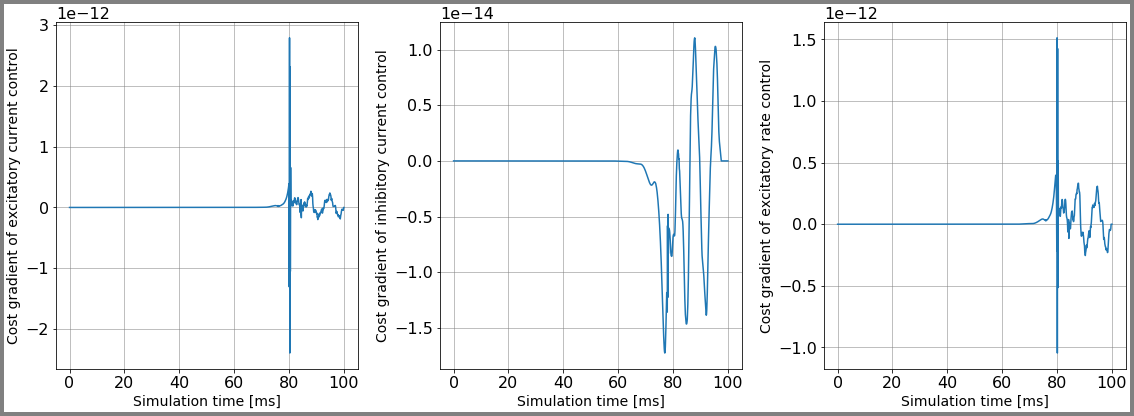

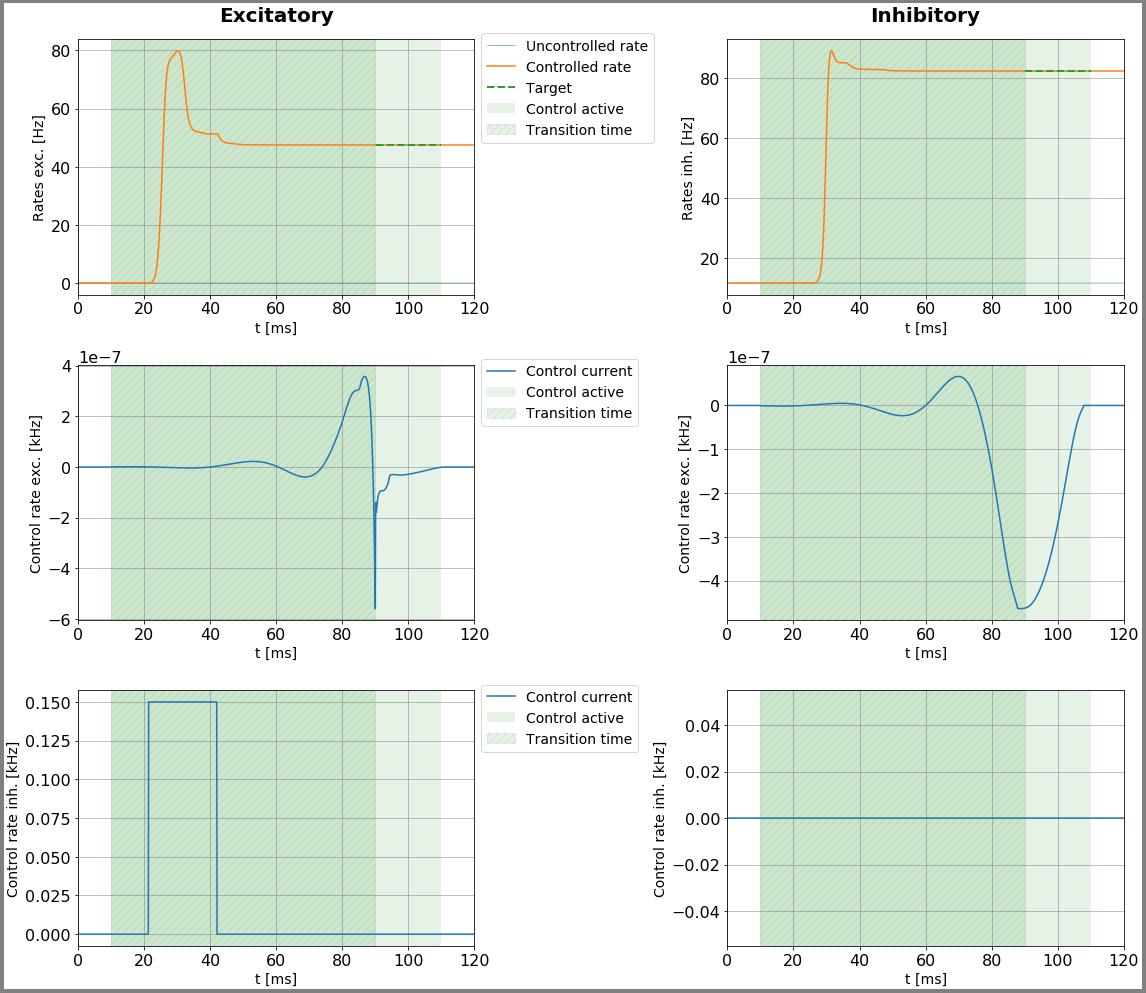

In [30]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
RUN  1 , total integrated cost =  34.020009982611114
RUN  2 , total integrated cost =  13.051086300642215
RUN  3 , total integrated cost =  12.897879490007034
RUN  4 , total integrated cost =  11.680778274834374
RUN  5 , total integrated cost =  9.426865733786634
RUN  6 , total integrated cost =  7.56265354019492
RUN  7 , total integrated cost =  6.085329180901578
RUN  8 , total integrated cost =  4.580225035638647
RUN  9 , total integrated cost =  3.431954787014844
RUN  10 , total integrated cost =  2.4112729196578
RUN  11 , total integrated cost =  1.4785314844973583
RUN  12 , total integrated cost =  0.6049848778435822
RUN  13 , total integrated cost =  0.27070931661218856
RUN  14 , total integrated cost =  0.20458909283881574
RUN  15 , total integrated cost =  0.20180410724960018
RUN  16 , total integrated cost =  0.20101012419552777
RUN  17 , total integrated cost =  0.200647

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.18321300730716397
RUN  5000 , total integrated cost =  0.18321300730716397
Improved over  5000  iterations by  99.99918548445892  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7146086893375598
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.100958438684007


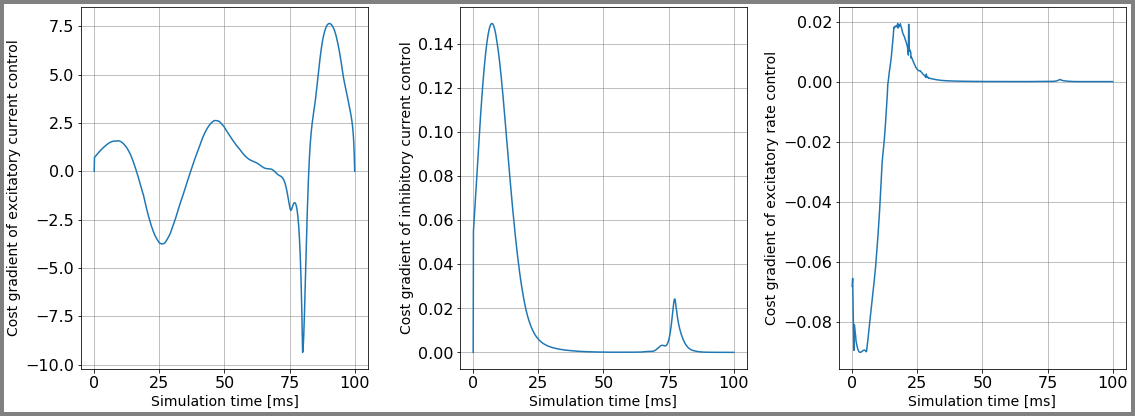

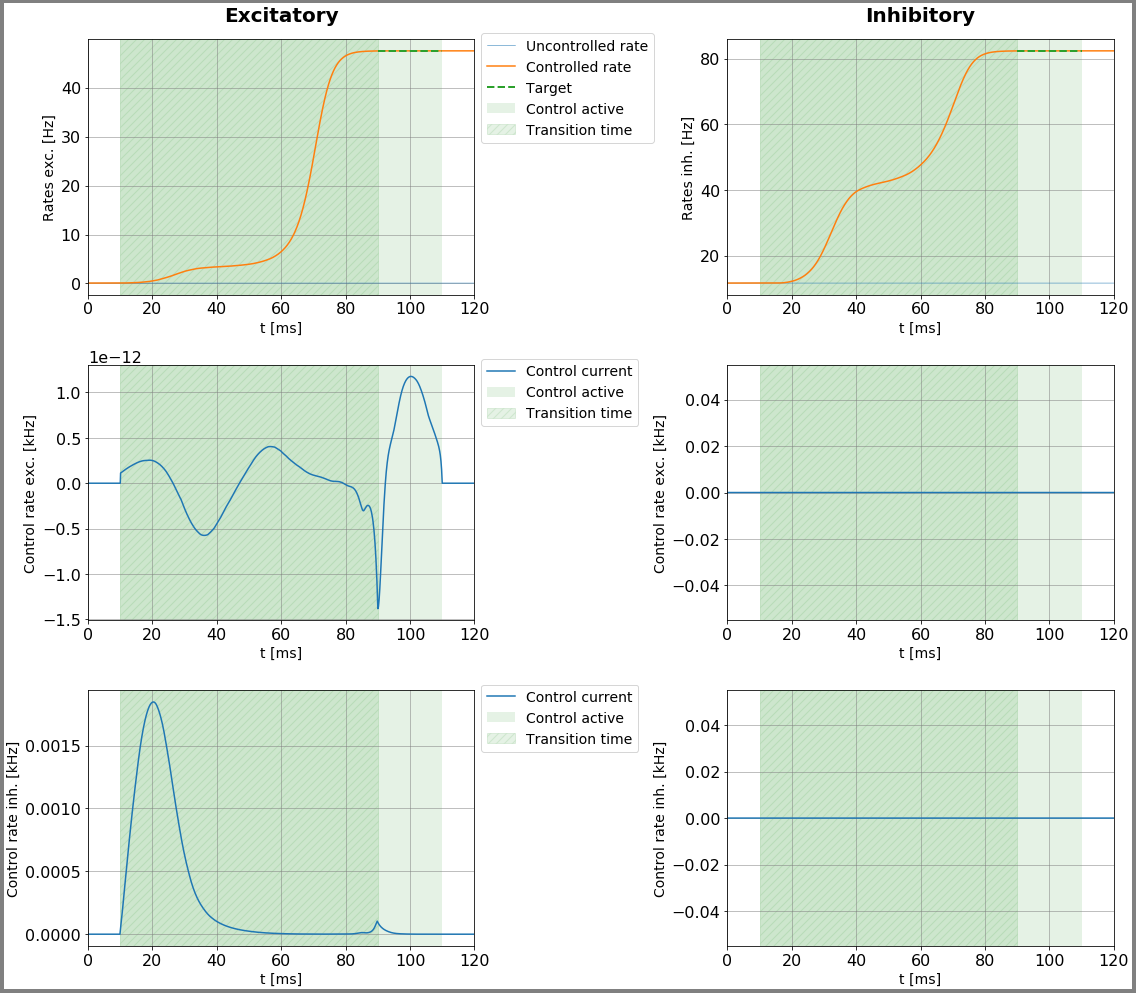

In [41]:
case_ind = 12
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )